## Predição - Perfomance de Aluno


At this project, our goal is to predict the student final_score. With a second aim, predict if it is a good or bad student.

# DATA WRANGLING


In [3]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# importing the dataset
df = pd.read_csv("Data/student_performance_interactions.csv", sep=",")

print(df.head())

  student_id  final_score grade  pass_fail  previous_score  math_prev_score  \
0      S0001    60.137241     D          1       60.599707        61.488212   
1      S0002    99.021977     A          1       92.289287        85.612565   
2      S0003    70.522955     C          1       80.259667        82.160656   
3      S0004    63.448537     D          1       72.926217        75.979145   
4      S0005    66.483019     C          1       48.581025        51.379977   

   science_prev_score  language_prev_score  daily_study_hours  \
0           53.568119            64.972292           1.427203   
1           91.873759            89.040461           4.813612   
2           72.736065            74.243663           1.240908   
3           76.726496            67.715995           2.190601   
4           48.993224            46.145011           2.192265   

   attendance_percentage  homework_completion_rate  sleep_hours  \
0              75.738405                 68.534371     6.809352   


In [5]:
# Categorical features

categorical_features = df.select_dtypes(include=["object"]).columns
print("Categorical features:", categorical_features)

Categorical features: Index(['student_id', 'grade', 'parent_education_level', 'study_environment'], dtype='str')


C:\Users\gabri\AppData\Local\Temp\ipykernel_3864\380202663.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns


In [6]:
df['parent_education_level'].unique()

<StringArray>
['Master', 'High School', 'Bachelor']
Length: 3, dtype: str

In [7]:
df['study_environment'].unique()

<StringArray>
['Noisy', 'Quiet', 'Moderate']
Length: 3, dtype: str

In [8]:
df['grade'].unique()

<StringArray>
['D', 'A', 'C', 'F', 'B']
Length: 5, dtype: str

In [9]:
df['parent_education_level'].value_counts()

parent_education_level
Master         351
High School    331
Bachelor       318
Name: count, dtype: int64

In [10]:
df['study_environment'].value_counts()

study_environment
Quiet       337
Moderate    336
Noisy       327
Name: count, dtype: int64

In [11]:
df['grade'].value_counts()

grade
C    338
D    304
B    182
A    106
F     70
Name: count, dtype: int64

In [12]:
# crosstab

crosstab_env_grade = pd.crosstab(df['study_environment'], df['grade'])
print(crosstab_env_grade)

grade               A   B    C    D   F
study_environment                      
Moderate           34  73  110   98  21
Noisy              32  52  116   97  30
Quiet              40  57  112  109  19


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 1000 non-null   str    
 1   final_score                1000 non-null   float64
 2   grade                      1000 non-null   str    
 3   pass_fail                  1000 non-null   int64  
 4   previous_score             1000 non-null   float64
 5   math_prev_score            1000 non-null   float64
 6   science_prev_score         1000 non-null   float64
 7   language_prev_score        1000 non-null   float64
 8   daily_study_hours          1000 non-null   float64
 9   attendance_percentage      1000 non-null   float64
 10  homework_completion_rate   1000 non-null   float64
 11  sleep_hours                1000 non-null   float64
 12  screen_time_hours          1000 non-null   float64
 13  physical_activity_minutes  1000 non-null   float64
 14  moti

In [14]:
df.describe()

,final_score,pass_fail,previous_score,math_prev_score,science_prev_score,language_prev_score,daily_study_hours,attendance_percentage,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation_score,exam_anxiety_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,70.935159,0.930000,66.964110,67.458590,67.033210,66.906063,2.984155,73.275703,79.755579,6.964696,3.475139,75.914922,6.973272,3.167954
std,14.376419,0.255275,16.067555,16.593689,17.105514,16.705229,1.158047,9.533937,12.360754,0.684015,1.395155,25.777316,1.780761,1.806371
min,37.364699,0.000000,40.254761,30.235250,25.752553,27.176600,1.003774,47.445725,51.604853,4.500750,1.000264,30.220913,4.000946,1.000000
25%,60.079082,1.000000,52.978530,53.098000,52.509398,53.562773,1.985539,66.256237,69.964528,6.518039,2.318330,54.076377,5.427378,1.369204
50%,70.673531,1.000000,67.324406,67.561105,66.133873,66.693546,2.934717,73.328172,79.393715,6.976139,3.472257,75.819676,6.910094,3.098631
75%,81.830057,1.000000,80.937577,81.380928,81.319085,80.269633,3.971015,80.230732,89.592788,7.413489,4.618956,98.505332,8.577936,4.600374
max,100.000000,1.000000,94.984472,104.984169,107.432492,107.561521,4.997401,99.111497,110.485203,9.353503,5.984953,119.970588,9.992500,8.535907


## EDA

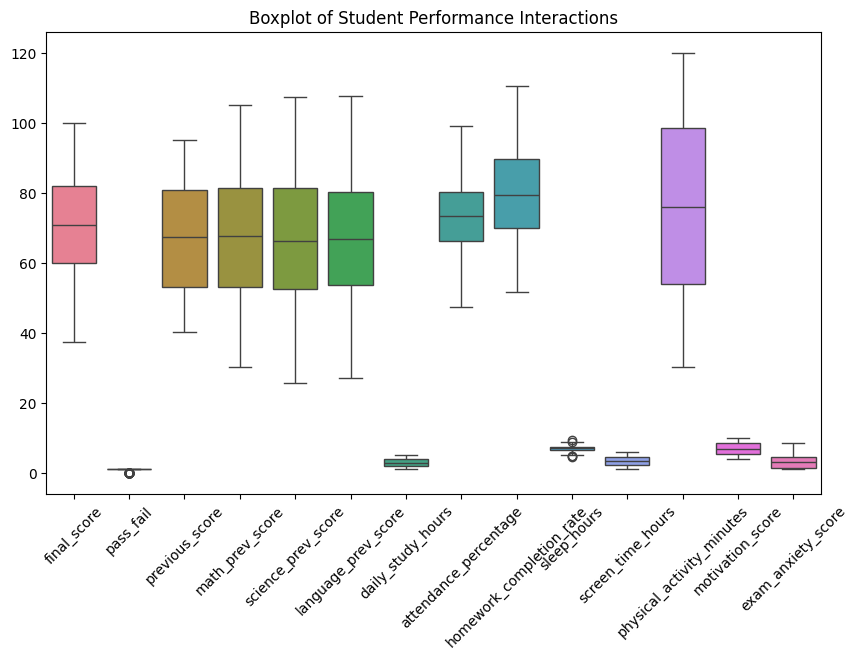

In [15]:
# Verifying outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Student Performance Interactions")
plt.xticks(rotation=45)
plt.show()

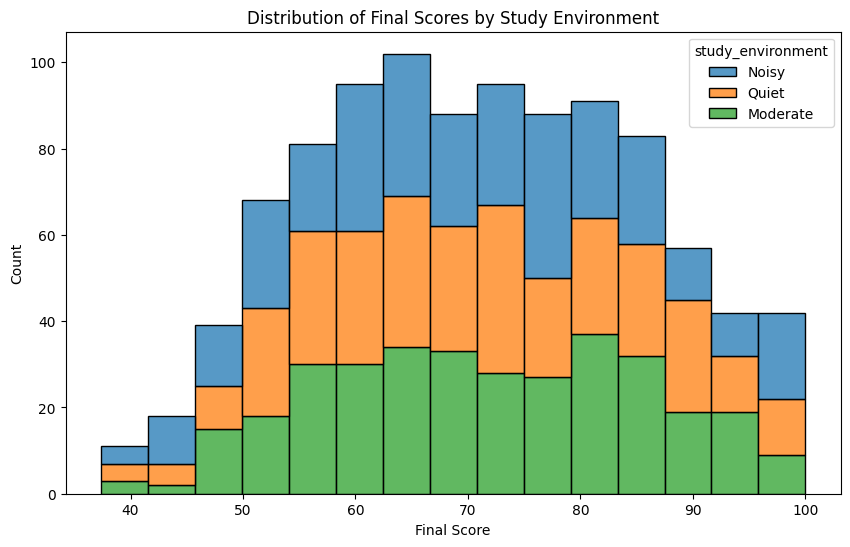

In [16]:
#Histogram categorial variable by target variable(final_score) and percentage of students in each category

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='final_score', hue='study_environment', multiple='stack')
plt.title("Distribution of Final Scores by Study Environment")
plt.xlabel("Final Score")
plt.ylabel("Count")
plt.show()



([0, 1, 2], [Text(0, 0, 'Noisy'), Text(1, 0, 'Quiet'), Text(2, 0, 'Moderate')])

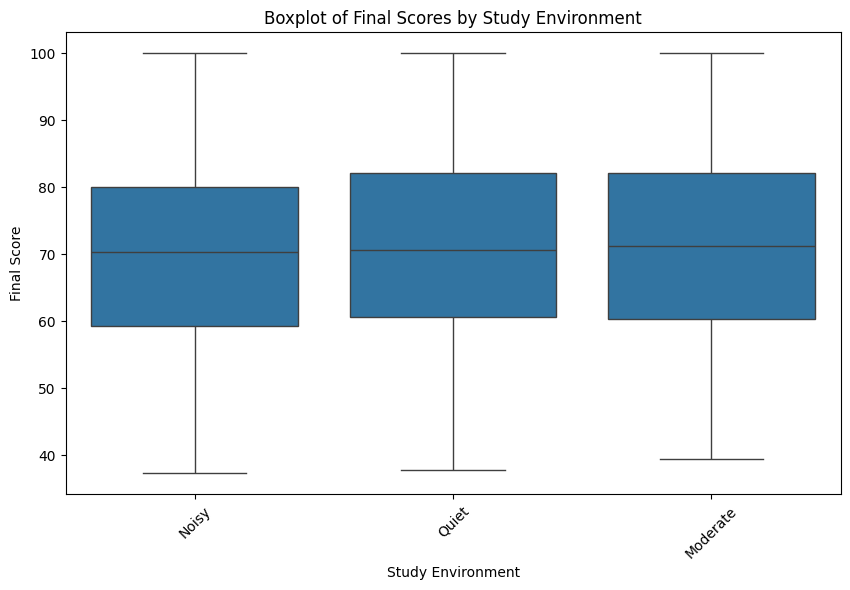

In [17]:
# Boxplot of final_score by study_environment

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='study_environment', y='final_score')
plt.title("Boxplot of Final Scores by Study Environment")
plt.xlabel("Study Environment")
plt.ylabel("Final Score")
plt.xticks(rotation=45)

In [18]:
# Dropping column of id
df_filter = df.drop("student_id", axis=1)

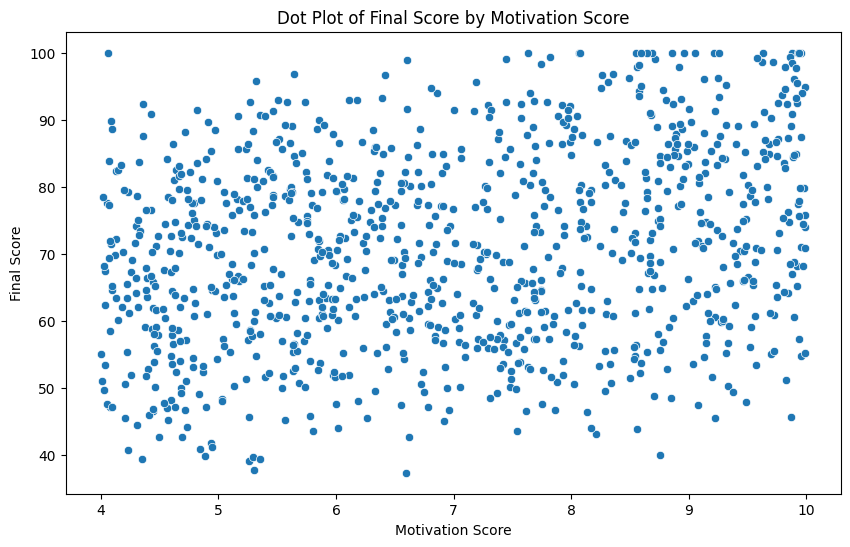

In [19]:
# Dot plot of final_score by motivation_score

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='motivation_score', y='final_score')
plt.title("Dot Plot of Final Score by Motivation Score")
plt.xlabel("Motivation Score")
plt.ylabel("Final Score")
plt.show()

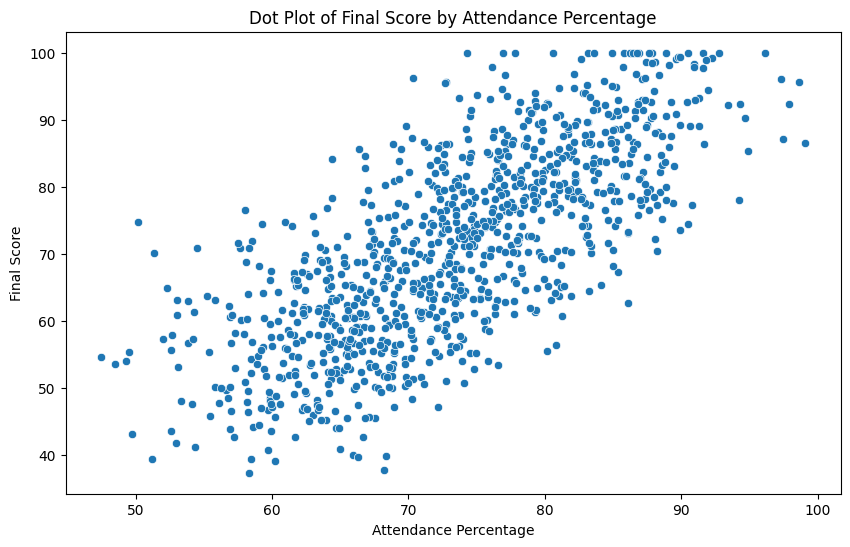

In [20]:
# Dot plot of final_score by attendance_percentage

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='attendance_percentage', y='final_score')
plt.title("Dot Plot of Final Score by Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Score")
plt.show()

In [ ]:
sns.pairplot(df)
plt.show()

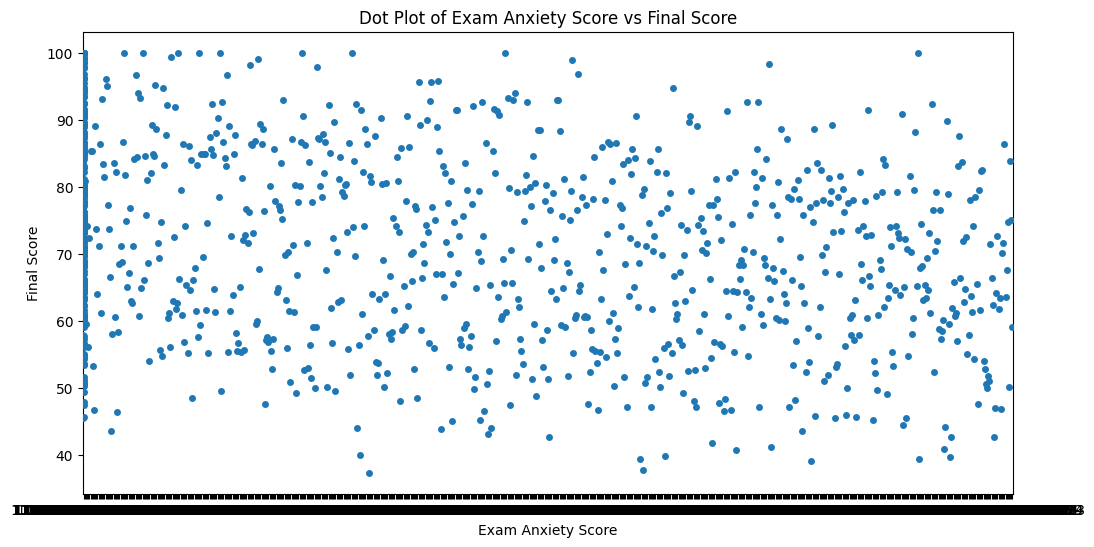

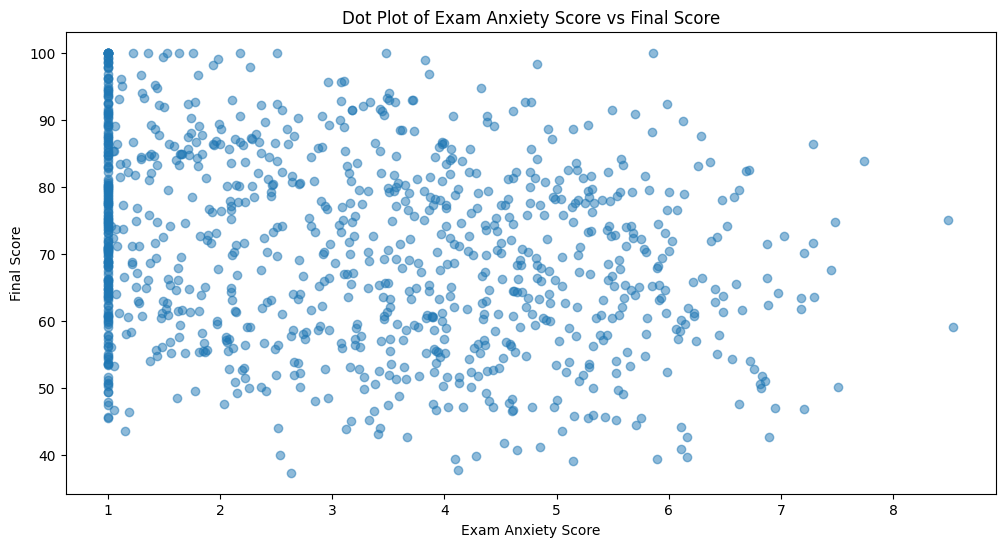

In [23]:
# Dot plot for the number of interactions per student
plt.figure(figsize=(12, 6))
sns.stripplot(x="exam_anxiety_score", y="final_score", data=df, jitter=True)
plt.title("Dot Plot of Exam Anxiety Score vs Final Score")
plt.xlabel("Exam Anxiety Score")
plt.ylabel("Final Score")
plt.show()

# Dot plot with matplotlib

plt.figure(figsize=(12, 6))
plt.scatter(df["exam_anxiety_score"], df["final_score"], alpha=0.5)
plt.title("Dot Plot of Exam Anxiety Score vs Final Score")
plt.xlabel("Exam Anxiety Score")
plt.ylabel("Final Score")
plt.show()

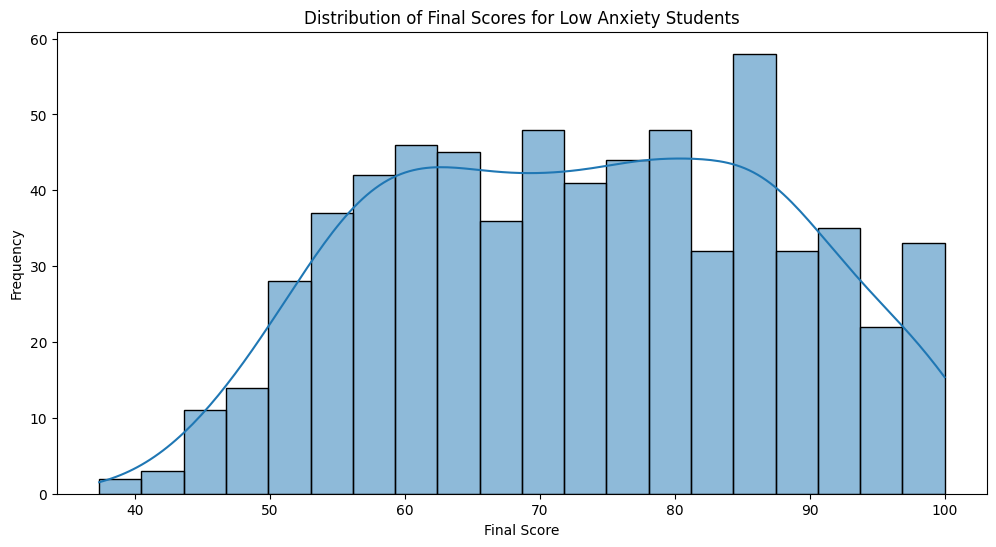

In [24]:
df_lowanxiety = df[df["exam_anxiety_score"] < 4]

# Distribution of final scores for low anxiety students
plt.figure(figsize=(12, 6))
sns.histplot(df_lowanxiety["final_score"], bins=20, kde=True)
plt.title("Distribution of Final Scores for Low Anxiety Students")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

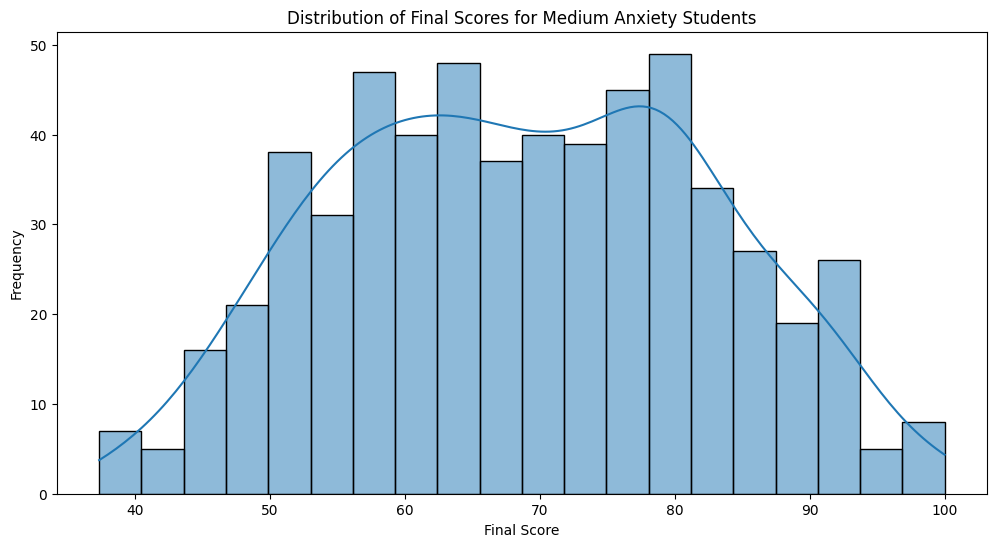

In [25]:
df_mediumanxiety = df[(df["exam_anxiety_score"] >= 2) & (df["exam_anxiety_score"] < 6)]
# Distribution of final scores for medium anxiety students
plt.figure(figsize=(12, 6))
sns.histplot(df_mediumanxiety["final_score"], bins=20, kde=True)
plt.title("Distribution of Final Scores for Medium Anxiety Students")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

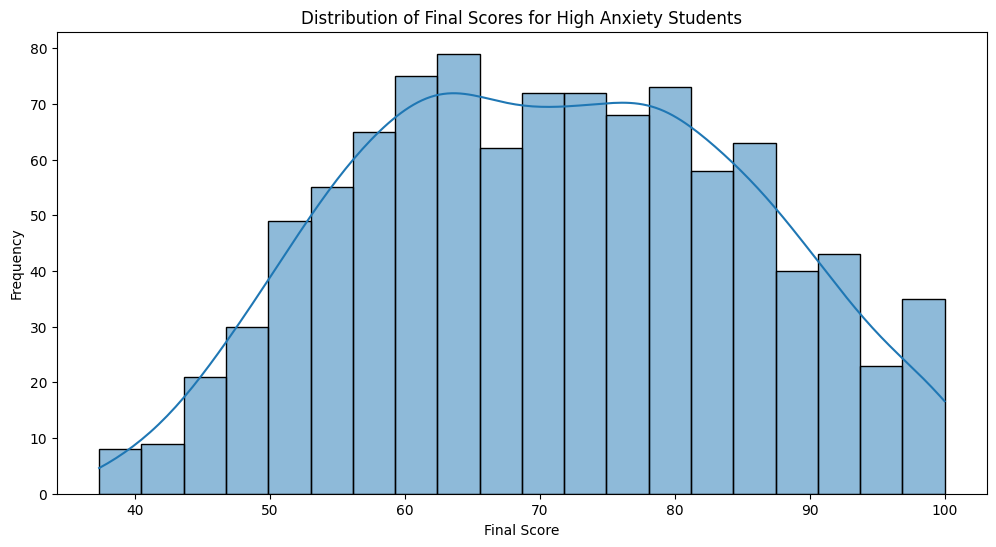

In [26]:
df_highanxiety = df[df["exam_anxiety_score"] >= 8]
# Distribution of final scores for high anxiety students
plt.figure(figsize=(12, 6))
sns.histplot(df["final_score"], bins=20, kde=True)
plt.title("Distribution of Final Scores for High Anxiety Students")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

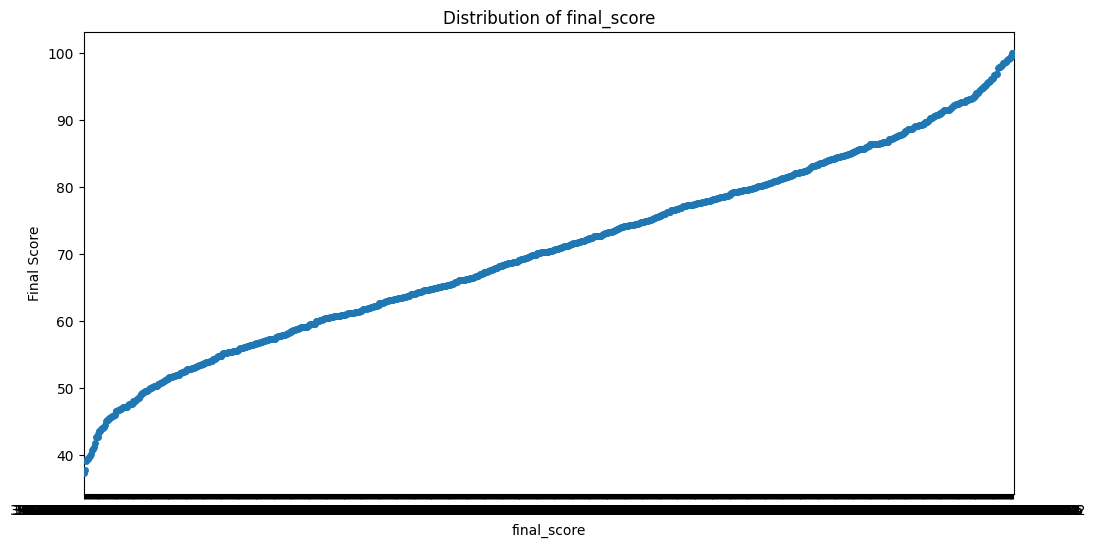

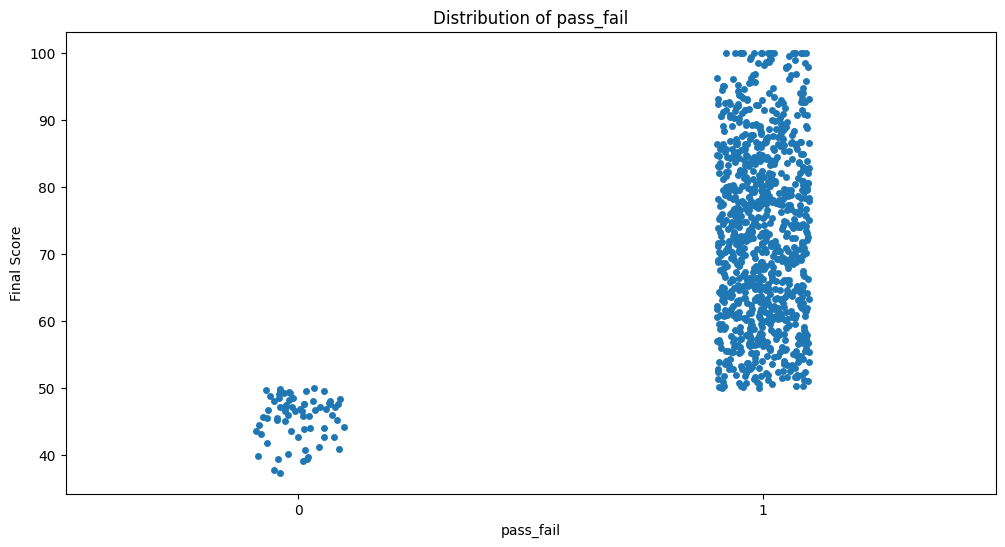

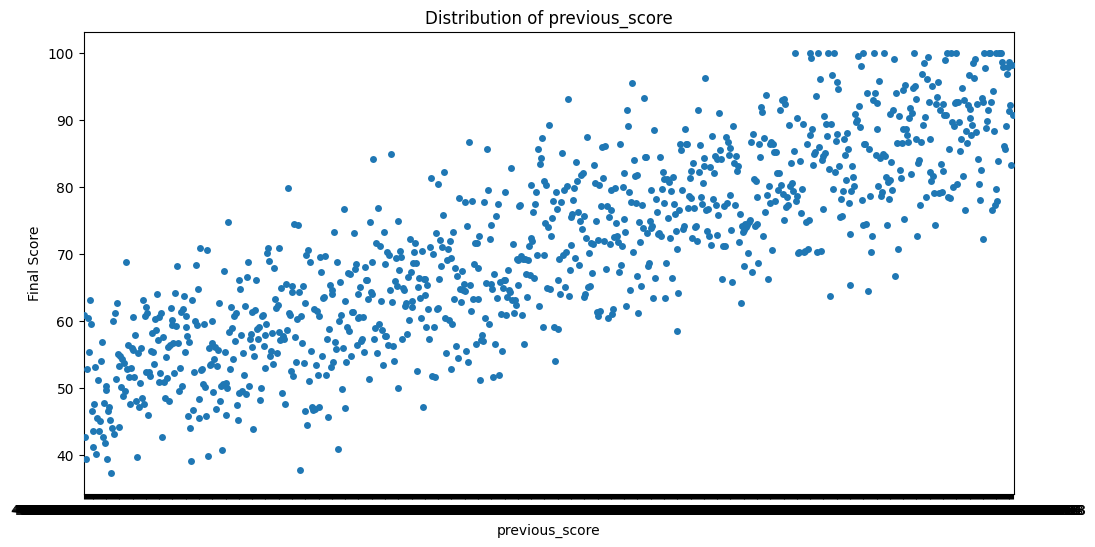

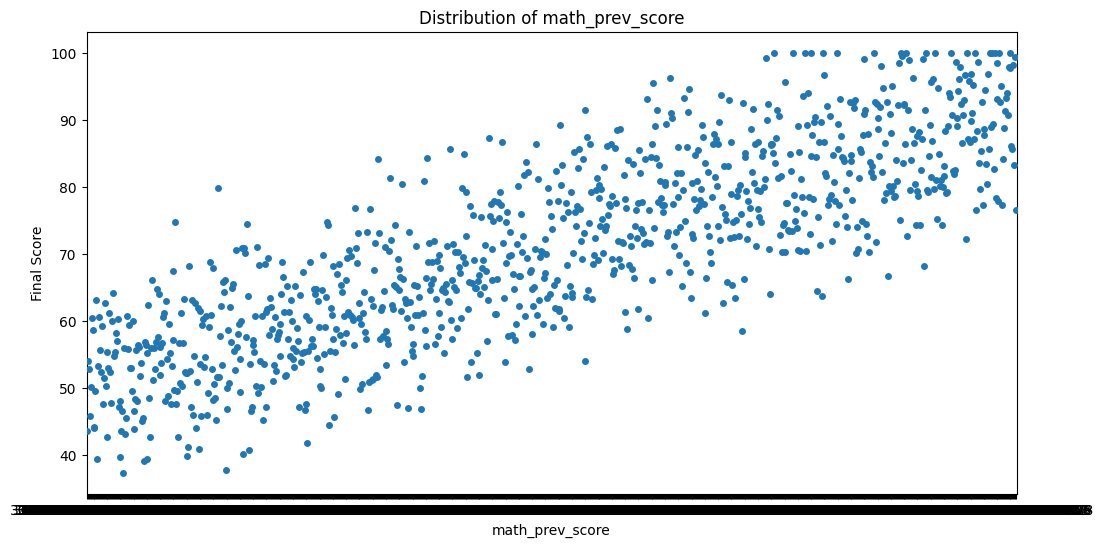

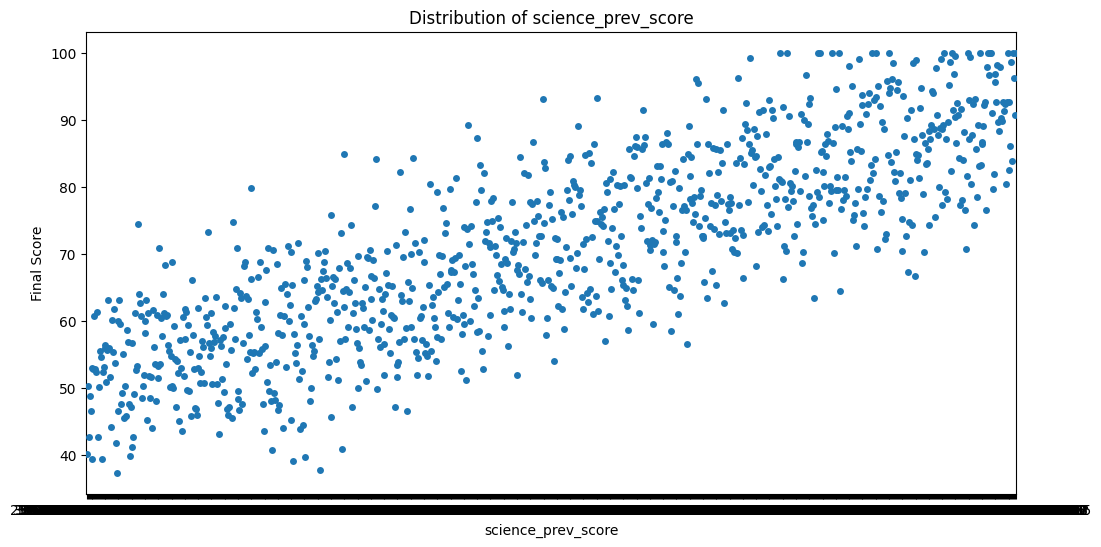

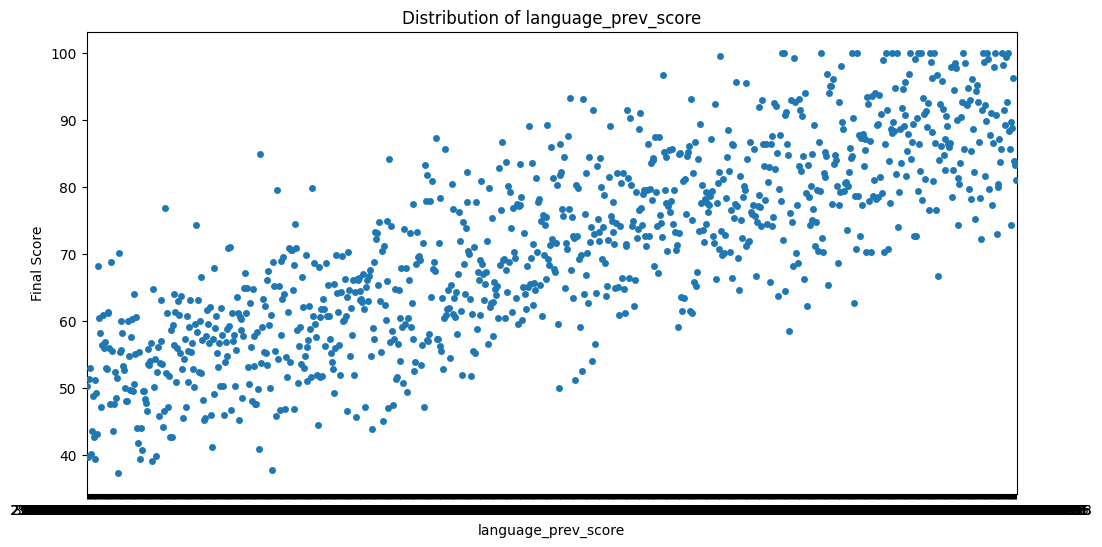

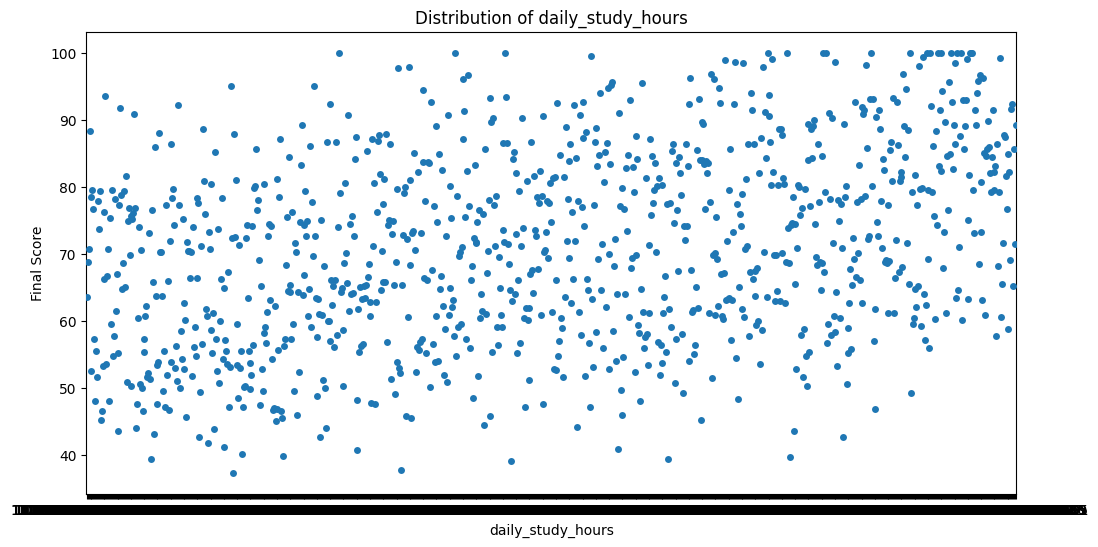

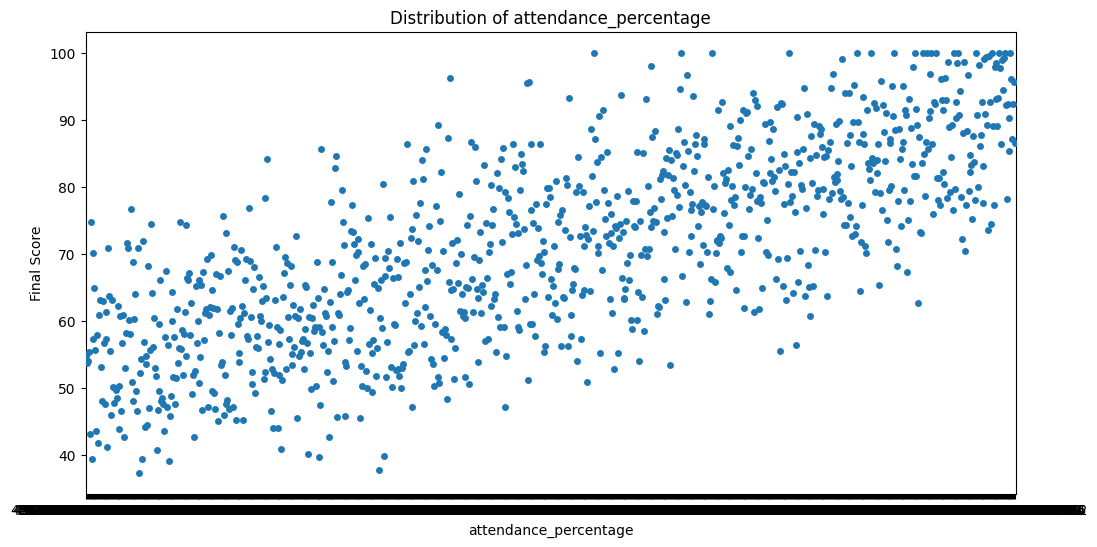

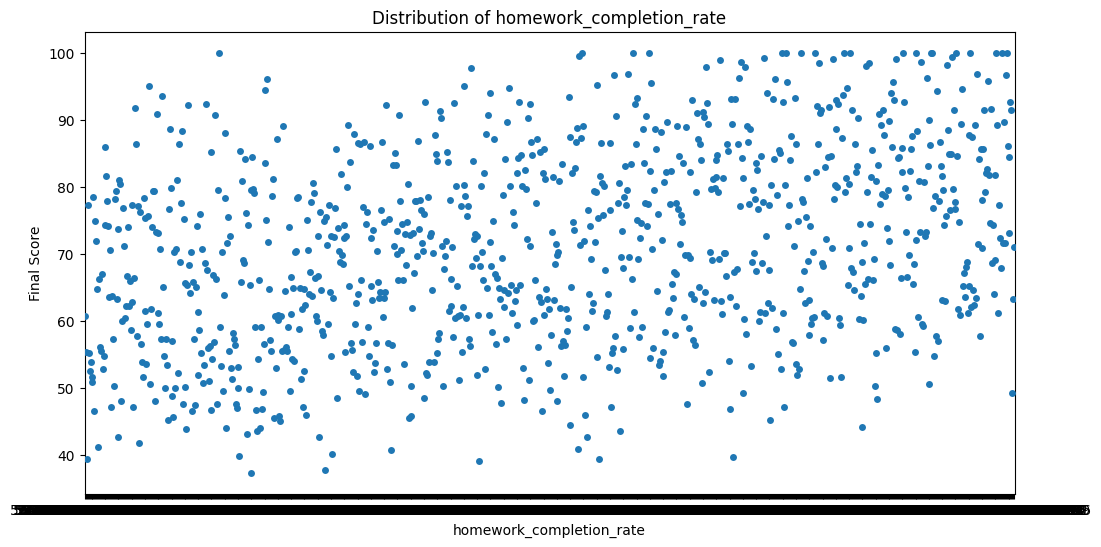

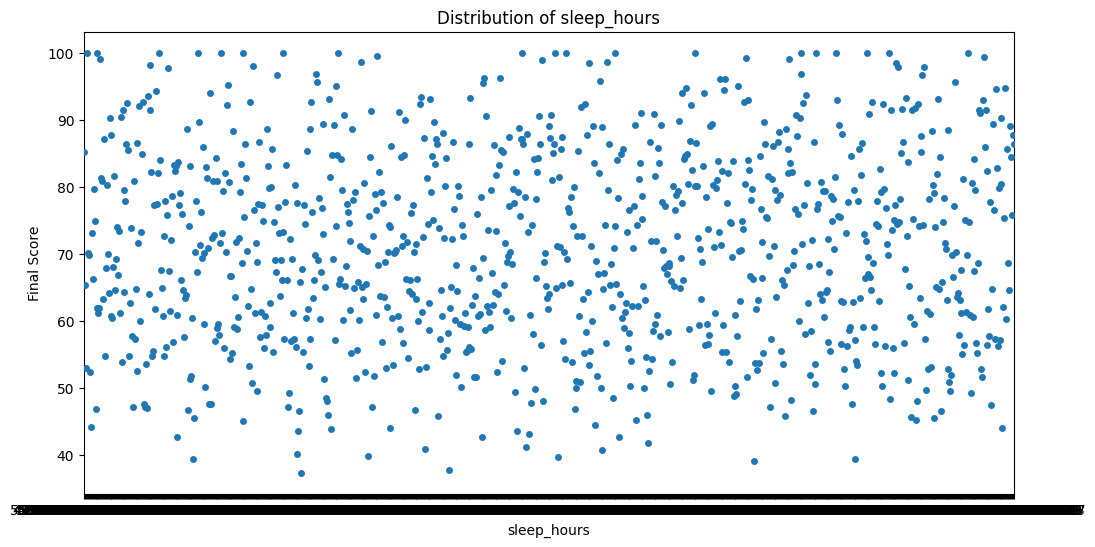

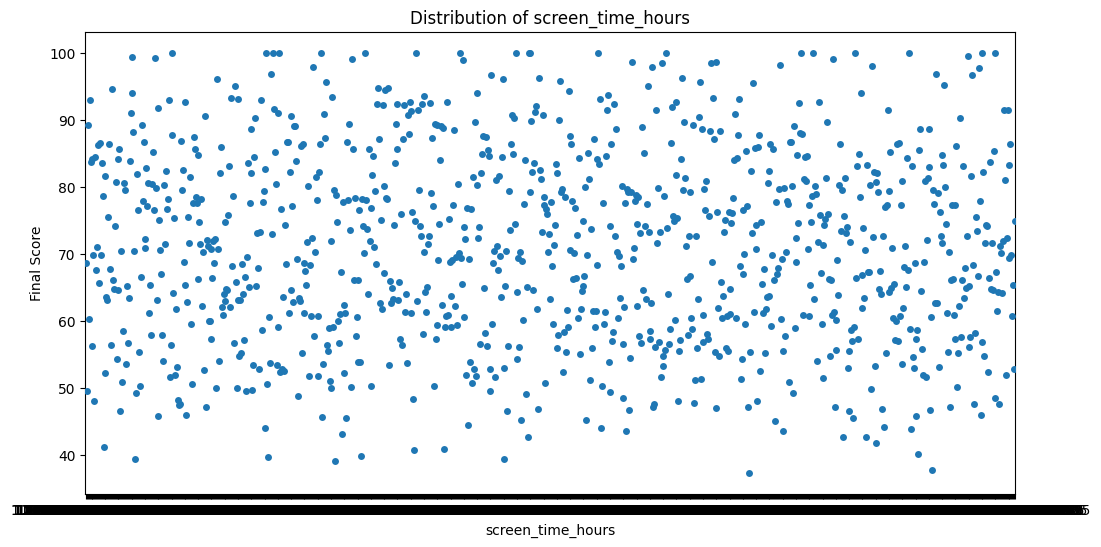

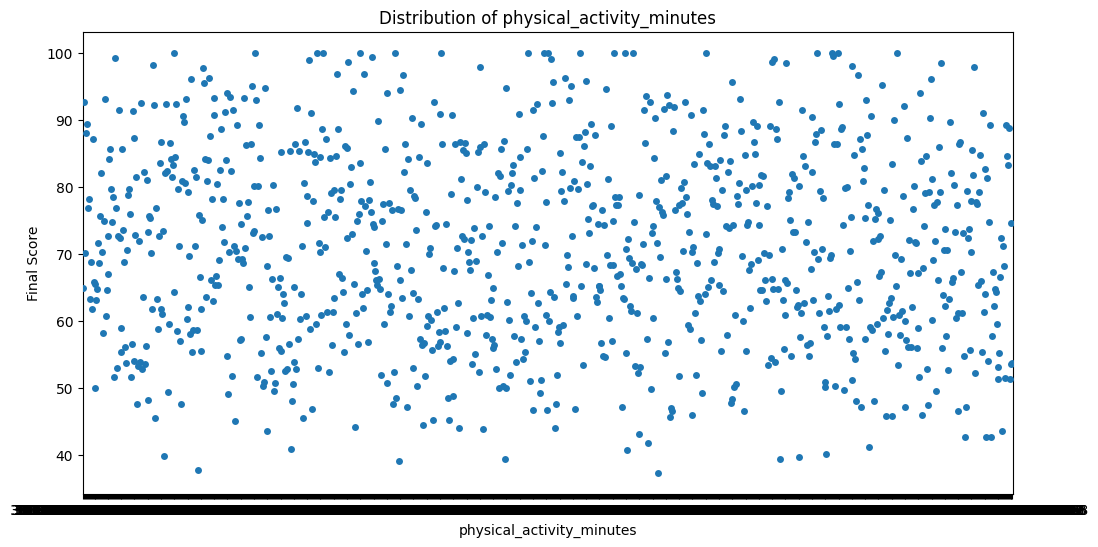

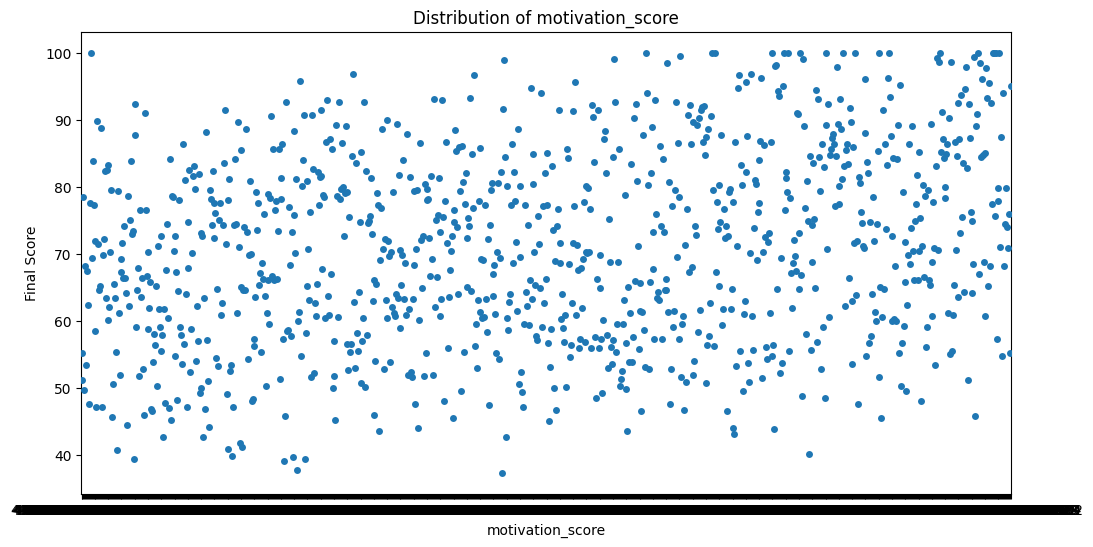

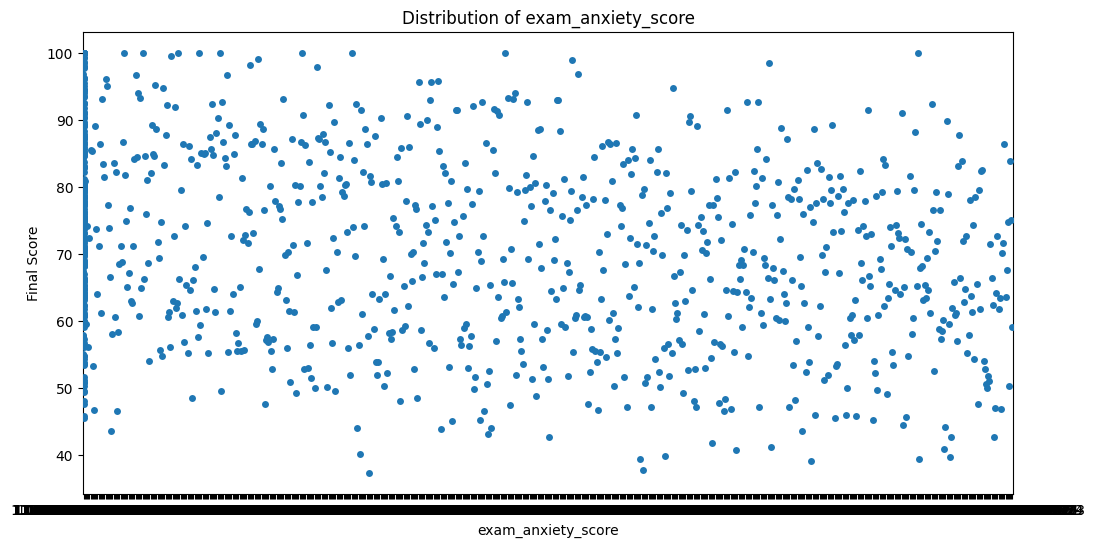

In [27]:
# loop for each numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.stripplot(x=col, y="final_score", data=df, jitter=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Final Score")
    plt.show()

In [28]:
# Statistical summary of final scores by each column

from scipy.stats import pearsonr, spearmanr

for col in numeric_cols:
    pearson_corr, _ = pearsonr(df[col], df["final_score"])
    spearman_corr, _ = spearmanr(df[col], df["final_score"])
    print(f"{col}: Pearson Correlation = {pearson_corr:.2f}, Spearman Correlation = {spearman_corr:.2f}")
    if abs(pearson_corr) > 0.5:
        print(f"  - {col} has a strong positive correlation with final_score.")
    if spearman_corr > 0.5:
        print(f"  - {col} has a strong positive monotonic relationship with final_score.")

final_score: Pearson Correlation = 1.00, Spearman Correlation = 1.00
  - final_score has a strong positive correlation with final_score.
  - final_score has a strong positive monotonic relationship with final_score.
pass_fail: Pearson Correlation = 0.48, Spearman Correlation = 0.44
previous_score: Pearson Correlation = 0.84, Spearman Correlation = 0.85
  - previous_score has a strong positive correlation with final_score.
  - previous_score has a strong positive monotonic relationship with final_score.
math_prev_score: Pearson Correlation = 0.83, Spearman Correlation = 0.84
  - math_prev_score has a strong positive correlation with final_score.
  - math_prev_score has a strong positive monotonic relationship with final_score.
science_prev_score: Pearson Correlation = 0.82, Spearman Correlation = 0.83
  - science_prev_score has a strong positive correlation with final_score.
  - science_prev_score has a strong positive monotonic relationship with final_score.
language_prev_score: Pearso

In [29]:
# Dropping columns with low correlation
threshold = 0.3
cols_to_drop = []
for col in numeric_cols:
    pearson_corr, _ = pearsonr(df[col], df["final_score"])
    if abs(pearson_corr) < threshold:
        cols_to_drop.append(col)
print(f"Columns to drop (Pearson correlation < {threshold}): {cols_to_drop}")

# Dropping the columns
df_new = df_filter.drop(columns=cols_to_drop, inplace=False)
df_new.columns

Columns to drop (Pearson correlation < 0.3): ['sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'motivation_score', 'exam_anxiety_score']


Index(['final_score', 'grade', 'pass_fail', 'previous_score',
       'math_prev_score', 'science_prev_score', 'language_prev_score',
       'daily_study_hours', 'attendance_percentage',
       'homework_completion_rate', 'parent_education_level',
       'study_environment'],
      dtype='str')

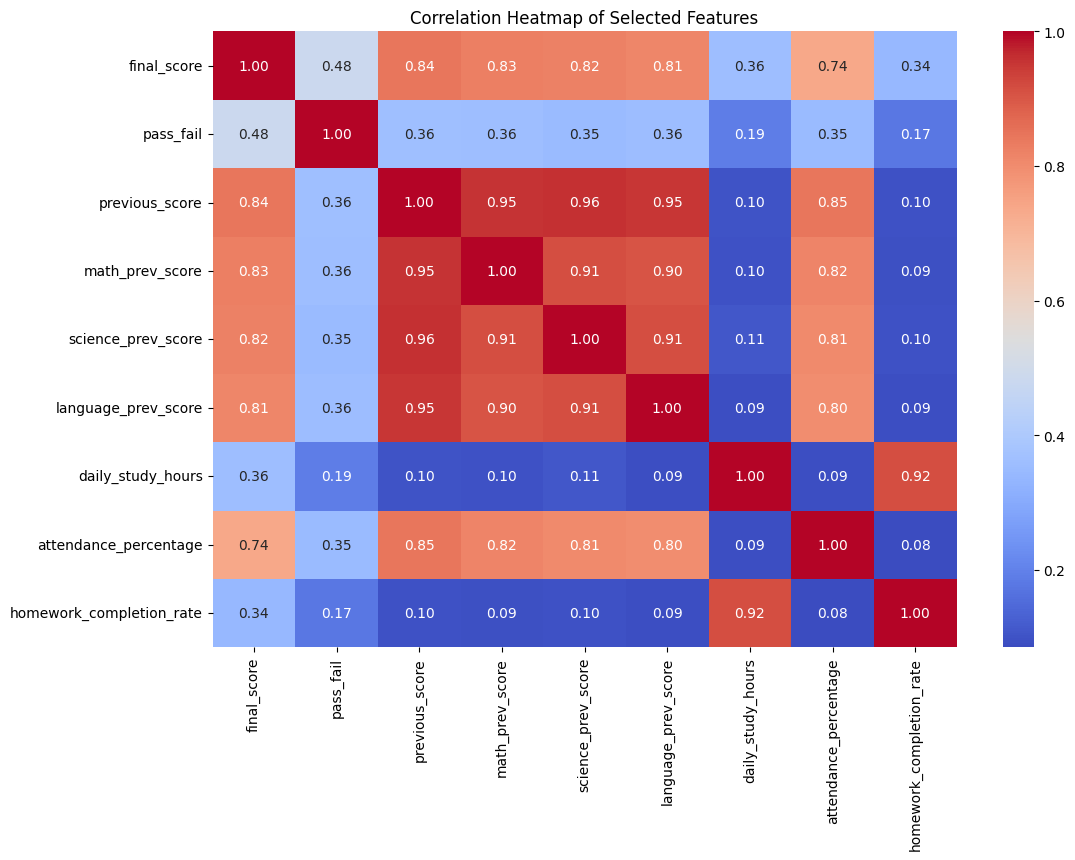

In [30]:
# heatmap of correlations
df_heatmap = df_new.drop(columns=["parent_education_level", "grade", "study_environment"], inplace=False)
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Features")
plt.show()

## Machine Learning Model Training

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer